In this Notebook I'll be creating an exercise classification model that takes videos as input.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

os.chdir('/content/drive/MyDrive/Project')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Project


In [8]:
!pip install torchcodec==0.9
!pip install "ffmpeg"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ffmpeg: filename=ffmpeg-1.4-py3-none-any.whl size=6083 sha256=cf0da36132279dcaf41e234ce8f426c5fe979bacbffc2798378a9f210c2136ed
  Stored in directory: /root/.cache/pip/wheels/26/21/0c/c26e09dff860a9071683e279445262346e008a9a1d2142c4ad
Successfully built ffmpeg


In [ ]:
import torch
import torchcodec

print(torch.__version__)
print(torchcodec.__version__)

2.9.0+cu126
0.9.0


I can't use ImageFolder here, because I will be loading videos. For this reason I will be using a custom Dataset class.

590


torch.Size([16, 3, 224, 224])
0


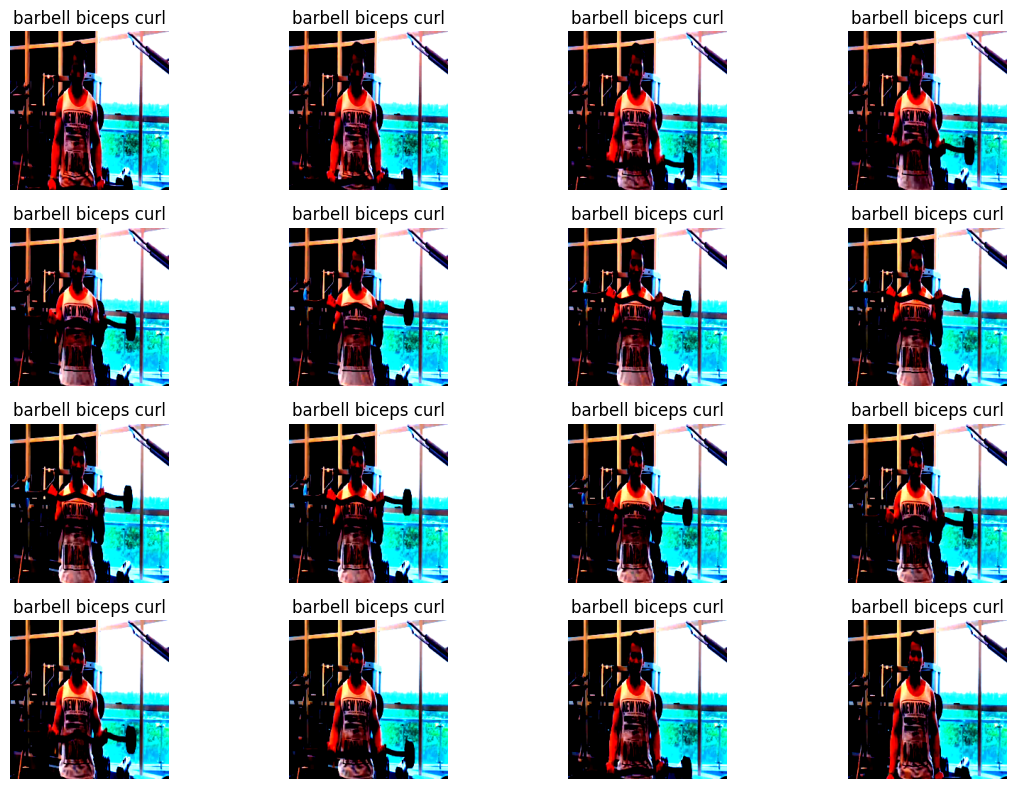

In [ ]:
import VideoDataset
import importlib
importlib.reload(VideoDataset)
from torchvision import transforms
import matplotlib.pyplot as plt

image_transforms = transforms.Compose([
  # transforms.ToTensor(),
  transforms.Resize((256, 256)), # resize the images
  transforms.CenterCrop(224),
  transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    #Normalizing the data to be zero-centered.
  #Initially I normalized it by using the
  #dataset mean and std, but I later changed it
  #to use the ImageNet normalization,
  #so that i can use the same data if i try
  #fine-tuning a model.
  ])

dataset = VideoDataset.VideoFolderDataset(
    root_dir="video_data",
    num_frames=16,
    transform=image_transforms
)

print(len(dataset))
video, label = dataset[0]

print(video.shape)
print(label)

rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    image = video[i].permute(1, 2, 0)
    label_idx = label
    label_name = dataset.classes[label_idx]

    ax.imshow(image)
    ax.set_title(label_name)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

print("Number of images:", len(dataset))
print("Number of classes:", len(dataset.classes))
print("Classes:", dataset.classes)

labels = [label for _, label in dataset.samples]
label_counts = Counter(labels)

total = len(dataset)
for label_idx, count in label_counts.items():
    pct = 100 * count / total
    print(f"{dataset.classes[label_idx]}: {pct:.2f}% ({count})")

#These are the classes for the image classification model
# barbell biceps curl: 5.09% (705)
# bench press: 4.51% (625)
# chest fly machine: 3.80% (527)
# deadlift: 3.83% (530)
# decline bench press: 3.71% (514)
# hammer curl: 3.94% (546)
# hip thrust: 4.02% (557)
# incline bench press: 5.26% (729)
# lat pulldown: 4.66% (646)
# lateral raises: 6.09% (843)
# leg extension: 4.23% (586)
# leg raises: 3.71% (514)
# plank: 7.17% (993)
# pull up: 4.44% (615)
# push up: 4.34% (601)
# romanian deadlift: 4.01% (555)
# russian twist: 3.77% (522)
# shoulder press: 3.70% (512)
# squat: 5.36% (742)
# t bar row: 4.82% (668)
# tricep dips: 5.04% (698)
# tricep pushdown: 4.51% (625)

Number of images: 590
Number of classes: 22
Classes: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'plank', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']
barbell biceps curl: 10.51% (62)
bench press: 10.34% (61)
chest fly machine: 4.75% (28)
deadlift: 5.42% (32)
decline bench press: 1.02% (6)
hammer curl: 2.03% (12)
hip thrust: 2.37% (14)
incline bench press: 5.59% (33)
lat pulldown: 8.64% (51)
lateral raise: 5.25% (31)
leg extension: 3.22% (19)
leg raises: 2.54% (15)
plank: 1.02% (6)
pull Up: 4.41% (26)
push-up: 9.49% (56)
romanian deadlift: 1.69% (10)
russian twist: 2.03% (12)
shoulder press: 2.20% (13)
squat: 3.90% (23)
t bar row: 2.37% (14)
tricep Pushdown: 8.47% (50)
tricep dips: 2.71% (16)


In [ ]:
video_to_image_label_mapper = [i for i in range(22)]
video_to_image_label_mapper[20] = 21
video_to_image_label_mapper[21] = 20

I have tried making the dataset class compatible with the ImageFolder class, so that I can copy the code from the image_classification notebook.

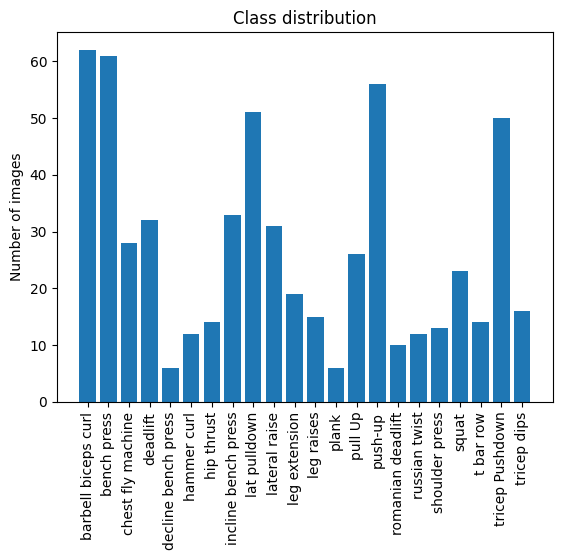

In [ ]:
import matplotlib.pyplot as plt

class_names = dataset.classes
counts = [label_counts[i] for i in range(len(class_names))]

plt.bar(class_names, counts)
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.xticks(class_names, rotation=90)
plt.show()


We see that there are some pretty big imbalances which we'll have to take into account when training models.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

labels = np.array([label for _, label in dataset.samples])
indices = np.arange(len(dataset))

#Dividing data into train and validation against test
#85% to 15%
train_val_idx, test_idx, y_train_val, y_test = train_test_split(
    indices,
    labels,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

#Dividing train against validation so that the data becomes:
#70% train
#15% validation
#15% test

train_idx, val_idx, y_train, y_val = train_test_split(
    train_val_idx,
    y_train_val,
    test_size=15/85,
    stratify=y_train_val,
    random_state=42)

from torch.utils.data import Subset

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

def count_labels(subset):
    labels = [dataset.samples[i][1] for i in subset.indices]
    return Counter(labels)

print("Train:", count_labels(train_dataset))
print("Val:  ", count_labels(val_dataset))
print("Test: ", count_labels(test_dataset))

Train: Counter({0: 44, 1: 43, 14: 39, 20: 35, 8: 35, 7: 23, 3: 22, 9: 21, 2: 20, 13: 18, 18: 16, 10: 13, 21: 12, 11: 11, 6: 10, 19: 10, 17: 9, 5: 8, 16: 8, 15: 7, 4: 4, 12: 4})
Val:   Counter({0: 9, 1: 9, 14: 9, 8: 8, 20: 7, 9: 5, 3: 5, 7: 5, 18: 4, 13: 4, 2: 4, 10: 3, 6: 2, 19: 2, 17: 2, 5: 2, 11: 2, 21: 2, 16: 2, 15: 1, 4: 1, 12: 1})
Test:  Counter({0: 9, 1: 9, 14: 8, 20: 8, 8: 8, 9: 5, 3: 5, 7: 5, 13: 4, 2: 4, 18: 3, 10: 3, 21: 2, 11: 2, 15: 2, 6: 2, 19: 2, 5: 2, 17: 2, 16: 2, 4: 1, 12: 1})


In [ ]:
from torch.utils import data

def create_dataloaders():
  batch_size = 1
  num_workers = 8 # This is used so that while the GPU trains,
  # the CPU prepares the next batch in parallel

  dataloader_train = data.DataLoader(
      train_dataset,
      shuffle=True,
      batch_size=batch_size,
      num_workers=num_workers,
      pin_memory=True
  )

  dataloader_val = data.DataLoader(
      val_dataset,
      shuffle=True,
      batch_size=batch_size,
      num_workers=num_workers,
      pin_memory=True
  )

  dataloader_test = data.DataLoader(
      test_dataset,
      shuffle=True,
      batch_size=batch_size,
      num_workers=num_workers,
      pin_memory=True
  )

  return dataloader_train, dataloader_val, dataloader_test


In [ ]:
dataloader_train, dataloader_val, dataloader_test = create_dataloaders()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print("Using device:", device)


True
1
Tesla T4
Using device: cuda


First I'll try using the best model trained on images on the 16 frames of the video and take the average of the results of all frames.

In [ ]:
from torchvision import models

model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
import torch.nn as nn

model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=22
)

model.load_state_dict(torch.load("model_05.pth", map_location=device))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 100MB/s] 


<All keys matched successfully>

In [ ]:
net = model.to(device)


with torch.no_grad():

  features, labels = next(iter(dataloader_test))
  features = features.squeeze()
  features = features.to(device)
  labels = labels.to(device)

  outputs = net(features)
  preds = torch.argmax(outputs, dim=1)
  mean_outputs = torch.mean(outputs, axis=0)
  pred = torch.argmax(mean_outputs)
  pred = video_to_image_label_mapper[pred]


In [ ]:
print(outputs)
print(preds)
print(mean_outputs)
print(pred)

tensor([[ -9.4239,  -4.7636,  -7.3286,  -2.2225,  -9.5355,  -1.8099,  16.0297,
         -12.0322, -15.8943, -10.9059, -11.2175, -11.1209, -12.5868, -14.8739,
          -2.5237, -11.7710, -14.1551, -17.6423, -10.9580, -14.8900,  -7.4761,
         -11.8415],
        [ -7.1869,  -7.3214,  -9.6484,  -4.2995,  -4.8115,  -5.6324,  15.0306,
         -13.7483, -17.2107, -11.5060, -10.0144, -11.9605, -14.6896, -16.1067,
          -6.2344, -11.7427, -10.4025, -14.2457, -10.7886, -13.8923,  -6.8310,
          -5.9833],
        [-10.3047,  -7.3541,  -9.1605,  -2.6644,  -5.9051,   0.0738,  11.6777,
         -15.4311, -11.8081,  -7.9141, -11.1498, -12.7271, -14.3612, -16.3721,
          -7.9731, -10.0472, -12.4785, -14.6372, -10.6426, -12.5153,  -8.8497,
         -11.4725],
        [ -9.2750,  -7.6516, -14.0807,  -4.0982,  -9.1467,  -6.1865,  16.6474,
         -13.1574, -20.0639, -12.2294, -12.5690, -10.3920, -16.8562, -15.8569,
          -9.3027, -10.1536, -14.6646, -12.8609,  -7.7822, -14.3954, -1

In [ ]:
import torch
from sklearn.metrics import f1_score, precision_score, recall_score
import pprint
from tqdm import tqdm

all_preds = []
all_labels = []
def print_metrics():

  net.eval()
  with torch.no_grad():
      for features, labels in tqdm(dataloader_test):
          features = features.squeeze()
          features = features.to(device)
          labels = labels.to(device)

          outputs = net(features)
          preds = torch.argmax(outputs, dim=1)
          mean_outputs = torch.mean(outputs, axis=0)
          pred = torch.argmax(mean_outputs)
          pred = video_to_image_label_mapper[pred]


          all_preds.append(pred)
          all_labels.append(labels.cpu())

  f1 = f1_score(all_labels, all_preds, average='macro')
  precision = precision_score(all_labels, all_preds, average='macro')
  recall = recall_score(all_labels, all_preds, average='macro')

  print(f"Summary statistics:")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1: {f1}")

  f1_per_class = f1_score(all_labels, all_preds, average=None)
  class_names = dataset.classes

  f1_dict = dict(zip(class_names, f1_per_class))

  pprint.pprint(f1_dict)

In [ ]:
print_metrics()

100%|██████████| 89/89 [02:51<00:00,  1.92s/it]

Summary statistics:
Precision: 0.9340909090909091
Recall: 0.9204545454545454
F1: 0.9217893217893219
{'barbell biceps curl': np.float64(1.0),
 'bench press': np.float64(0.8571428571428571),
 'chest fly machine': np.float64(0.8888888888888888),
 'deadlift': np.float64(1.0),
 'decline bench press': np.float64(0.0),
 'hammer curl': np.float64(1.0),
 'hip thrust': np.float64(1.0),
 'incline bench press': np.float64(1.0),
 'lat pulldown': np.float64(1.0),
 'lateral raise': np.float64(1.0),
 'leg extension': np.float64(1.0),
 'leg raises': np.float64(1.0),
 'plank': np.float64(1.0),
 'pull Up': np.float64(1.0),
 'push-up': np.float64(0.9333333333333333),
 'romanian deadlift': np.float64(1.0),
 'russian twist': np.float64(1.0),
 'shoulder press': np.float64(0.6666666666666666),
 'squat': np.float64(1.0),
 't bar row': np.float64(1.0),
 'tricep Pushdown': np.float64(0.9333333333333333),
 'tricep dips': np.float64(1.0)}



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


We got some pretty good results! Let's see if it can get better by using a more complex model. My next idea is to try to use a RNN that takes as input the 4096-dimensional vector that the semi-last layer of the VGG model outputs for each frame.

In [ ]:
y_pred_mean = all_preds
y_mean = all_labels

To train the RNN model it will be faster if i first create a dataset that contains entries in the form: (output of image classification model for the frames of the vide, label) where the first value is a list of 4096-d vectors. (2D vector with shape (16, 4096))

In [ ]:
from tqdm import tqdm

def build_vector_dataset(dataloader):
    X = []
    y = []

    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    model.classifier[6] = nn.Linear(
        in_features=4096,
        out_features=22
    )

    model.load_state_dict(torch.load("model_05.pth", map_location=device))
    #removing the last layer so that the model returns 4096D vector
    model.classifier[6] = nn.Identity()
    model = model.to(device)

    model.eval()
    for features, labels in tqdm(dataloader):

        with torch.no_grad():
            features = features.squeeze()
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)

            X.append(outputs.cpu())
            y.append(labels[0])

    return X, y


In [ ]:
X_train, y_train = build_vector_dataset(dataloader_train)

100%|██████████| 412/412 [11:44<00:00,  1.71s/it]


In [ ]:
print(len(X_train))
print(len(y_train))

print(type(X_train))
print(type(y_train[0]))
print(X_train[0].shape)

412
412
<class 'numpy.ndarray'>
<class 'torch.Tensor'>
(16, 4096)


In [ ]:
X_val, y_val = build_vector_dataset(dataloader_val)
X_test, y_test = build_vector_dataset(dataloader_test)

  0%|          | 0/89 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 89/89 [02:39<00:00,  1.79s/it]


In [ ]:
print(len(X_val))
print(len(y_val))
print(X_val[0].shape)

print(len(X_test))
print(len(y_test))
print(X_test[0].shape)

89
89
torch.Size([16, 4096])
89
89
torch.Size([16, 4096])


In [ ]:
torch.save({
    "X_train": X_train,
    "y_train": y_train
}, "vector_train_dataset.pt")

In [ ]:
torch.save({
    "X_val": X_val,
    "y_val": y_val
}, "vector_val_dataset.pt")

In [ ]:
torch.save({
    "X_test": X_test,
    "y_test": y_test
}, "vector_test_dataset.pt")

In [ ]:
vector_train_dataset=torch.load("vector_train_dataset.pt")
X_train = vector_train_dataset["X_train"]
y_train = vector_train_dataset["y_train"]

vector_val_dataset=torch.load("vector_val_dataset.pt")
X_val = vector_val_dataset["X_val"]
y_val = vector_val_dataset["y_val"]

vector_test_dataset=torch.load("vector_test_dataset.pt")
X_test = vector_test_dataset["X_test"]
y_test = vector_test_dataset["y_test"]

In [ ]:
import numpy as np

label_counts = 1 / np.array(counts) #getting the inverse counts
#because i want the class with more count to have less weight
class_weights = label_counts / np.sum(label_counts)

print(class_weights)
print(np.sum(class_weights))


[0.01237809 0.01258101 0.02740862 0.02398254 0.1279069  0.06395345
 0.05481724 0.0232558  0.01504787 0.02475617 0.04039165 0.05116276
 0.1279069  0.02951698 0.01370431 0.07674414 0.06395345 0.05903395
 0.03336702 0.05481724 0.01534883 0.04796509]
1.0


In [ ]:
y_train = [y.cpu().item() for y in y_train]

In [ ]:
y_val = [y.cpu().item() for y in y_val]
y_test = [y.cpu().item() for y in y_test]

In [ ]:
from torch.utils.data import TensorDataset



X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = np.array(X_test)
y_test = np.array(y_test)


# Convert to torch tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

dataloader_train, dataloader_val, dataloader_test = create_dataloaders()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[0.01237809 0.01258101 0.02740862 0.02398254 0.1279069  0.06395345
 0.05481724 0.0232558  0.01504787 0.02475617 0.04039165 0.05116276
 0.1279069  0.02951698 0.01370431 0.07674414 0.06395345 0.05903395
 0.03336702 0.05481724 0.01534883 0.04796509]


100%|██████████| 412/412 [00:07<00:00, 53.18it/s]


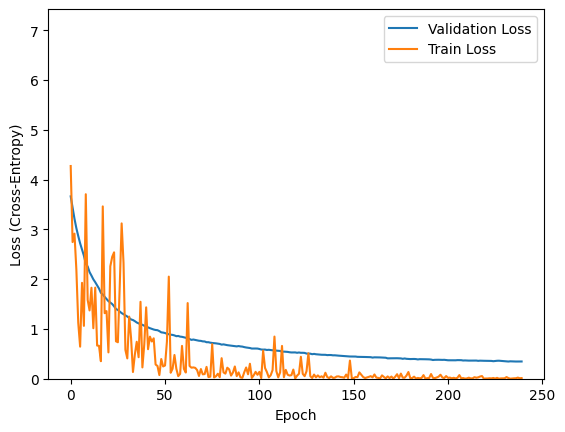

Total time taken to train the model in seconds: 256.8643181324005


In [ ]:
import torch.optim as optim
import time
import pprint
import importlib
import train_model
import RNN

importlib.reload(train_model)
importlib.reload(RNN)

model = RNN.RNN()
net = model.to(device)
learning_rate = 5e-6
optimizer = optim.AdamW(net.parameters(), lr = learning_rate)

print(class_weights)

start_time = time.time()
loss_history = train_model.train_model(dataloader_train, dataloader_val, optimizer, net, 30, device, True,class_weights=class_weights, print_every_50_batches=True, save_best_model_as="video_model_01.pth")
end_time = time.time()

total_time_taken = end_time - start_time
print(f"Total time taken to train the model in seconds: {total_time_taken}")


In [ ]:
import torch
from sklearn.metrics import f1_score, precision_score, recall_score
import pprint
from tqdm import tqdm

all_preds = []
all_labels = []
def print_metrics_rnn():

  net.eval()
  with torch.no_grad():
      for features, labels in tqdm(dataloader_test):
          features = features.to(device)
          labels = labels.to(device)

          outputs = net(features)
          pred = torch.argmax(outputs, dim=1)


          all_preds.append(pred.cpu())
          all_labels.append(labels.cpu())

  f1 = f1_score(all_labels, all_preds, average='macro')
  precision = precision_score(all_labels, all_preds, average='macro')
  recall = recall_score(all_labels, all_preds, average='macro')

  print(f"Summary statistics:")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1: {f1}")

  f1_per_class = f1_score(all_labels, all_preds, average=None)
  class_names = dataset.classes

  f1_dict = dict(zip(class_names, f1_per_class))

  pprint.pprint(f1_dict)

In [ ]:
print_metrics_rnn()

100%|██████████| 89/89 [00:00<00:00, 135.20it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Summary statistics:
Precision: 0.881818181818182
Recall: 0.8522727272727273
F1: 0.8577484060174744
{'barbell biceps curl': np.float64(1.0),
 'bench press': np.float64(0.9473684210526315),
 'chest fly machine': np.float64(0.8571428571428571),
 'deadlift': np.float64(1.0),
 'decline bench press': np.float64(0.0),
 'hammer curl': np.float64(1.0),
 'hip thrust': np.float64(1.0),
 'incline bench press': np.float64(0.9090909090909091),
 'lat pulldown': np.float64(0.9411764705882353),
 'lateral raise': np.float64(1.0),
 'leg extension': np.float64(1.0),
 'leg raises': np.float64(0.6666666666666666),
 'plank': np.float64(0.0),
 'pull Up': np.float64(1.0),
 'push-up': np.float64(0.9411764705882353),
 'romanian deadlift': np.float64(1.0),
 'russian twist': np.float64(1.0),
 'shoulder press': np.float64(0.6666666666666666),
 'squat': np.float64(1.0),
 't bar row': np.float64(1.0),
 'tricep Pushdown': np.float64(0.9411764705882353),
 'tricep dips': np.float64(1.0)}


In [ ]:
y_pred_rnn = all_preds
y_rnn = all_labels

In [ ]:
import create_model_report

importlib.reload(create_model_report)

import openpyxl
wb = openpyxl.Workbook()
wb.create_sheet('ModelReport')
ws = wb['ModelReport']


create_model_report.append_first_row(ws)

base_model, base_model_recall, base_model_precision, base_model_f1 = create_model_report.base_model(y_test,ws)

models = [
    base_model,
     {
    'name': '#1 Mean frame prediction',
    'scaling':None,
    'cv':None,
    'y':y_mean,
    'y_pred':y_pred_mean
},
{
    'name': '#2 RNN',
    'scaling':None,
    'cv':None,
    'y':y_rnn,
    'y_pred':y_pred_rnn
}]

for m in models:
    print(m["name"])
    create_model_report.add_model_report_row(
        ws=ws,
        model_name=m["name"],
        y_test=m['y'],
        y_pred=m["y_pred"],
        label_names=dataset.classes,
        base_model_precision=base_model_precision,
        base_model_recall=base_model_recall,
        base_model_f1=base_model_f1,
        diagrams_dir='./diagrams',
        scaling=m["scaling"],
        cv=m["cv"],
        export_to_file=True
    )


Base Model


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#1 Mean frame prediction


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#2 RNN


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
wb.save("model_report_video_classification.xlsx")

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 44.2 MB/s eta 0:00:00


In [2]:
!pip install -q streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 122.9 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.1.2) ...
Setting up cloudflared (2026.1.2) ...
Processing triggers for man-db (2.10.2-1) ...


In [25]:
!nohup streamlit run application_demo.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &


In [26]:
!lsof -i :8501


COMMAND     PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
streamlit 14407 root   13u  IPv4 426624      0t0  TCP *:8501 (LISTEN)


In [27]:
!cat streamlit.log





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.199.127.208:8501



In [28]:
!cloudflared tunnel --url http://127.0.0.1:8501


2026-02-04T17:15:18Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-02-04T17:15:18Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-02-04T17:15:21Z INF +--------------------------------------------------------------------------------------------+
2026-02-04T17:15:21Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-02-04T17:15:21Z INF |  https://pictures-patrick-whether-catering.trycloudfla